In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. LOAD THE DATA
df = pd.read_csv('Refined_Physics_Data_V2.csv')

# 2. HOT-FIX: RE-ADDING MISSING PHYSICS COLUMNS
def get_b_site(formula):
    if 'Pb' in formula: return 'Pb'
    if 'Sn' in formula: return 'Sn'
    if 'Ge' in formula: return 'Ge'
    if 'Ti' in formula: return 'Ti'
    return 'Other'

df['B_site'] = df['formula'].apply(get_b_site)
df['Stability_Tag'] = df['tolerance_factor'].apply(lambda t: 1 if 0.8 <= t <= 1.1 else 0)

# 3. CREATE THE TARGET LABEL
# 1 = Semiconductor (Bandgap > 0), 0 = Metal (Bandgap == 0)
df['is_semiconductor'] = (df['band_gap'] > 0).astype(int)

# 4. ENCODE THE B-SITE (Convert 'Pb', 'Sn' etc. into numbers 0, 1, 2...)
# Machine Learning models can only read numbers, not words.
le = LabelEncoder()
df['B_site_encoded'] = le.fit_transform(df['B_site'])

print(f"✅ Step 3 Initialized with Physics Hot-Fix.")
print(f"B-site classes found: {le.classes_}")
print(f"Total Materials: {len(df)}")

# 5. PREPARE X AND y
# We drop non-numeric labels and the band_gap itself
X = df.drop(['formula', 'band_gap', 'is_semiconductor', 'B_site'], axis=1)
y = df['is_semiconductor']

# 6. TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\n--- Data Split Summary ---")
print(f"Training Set: {len(X_train)} samples")
print(f"Testing Set: {len(X_test)} samples")
print(f"Semiconductor Percentage: {(y.mean()*100):.2f}%")

✅ Step 3 Initialized with Physics Hot-Fix.
B-site classes found: ['Ge' 'Other' 'Pb' 'Sn' 'Ti']
Total Materials: 4012

--- Data Split Summary ---
Training Set: 3209 samples
Testing Set: 803 samples
Semiconductor Percentage: 45.64%


Training the Gatekeeper AI...

--- Classification Results ---
Overall Accuracy: 82.57%


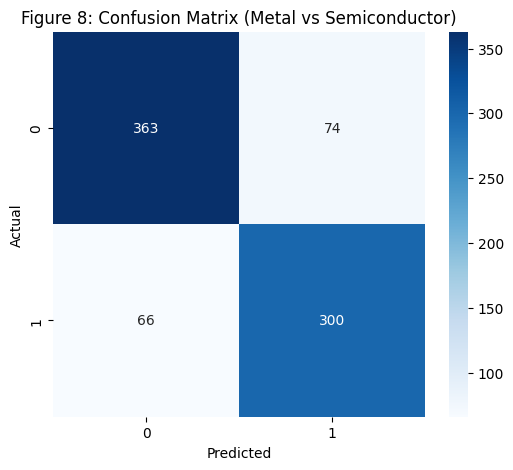


Detailed Performance Report:
              precision    recall  f1-score   support

           0       0.85      0.83      0.84       437
           1       0.80      0.82      0.81       366

    accuracy                           0.83       803
   macro avg       0.82      0.83      0.82       803
weighted avg       0.83      0.83      0.83       803



In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. INITIALIZE THE MODEL
# n_estimators=100 means we are using 100 decision trees to vote
clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# 2. TRAIN THE MODEL (The 'Study' Phase)
print("Training the Gatekeeper AI...")
clf.fit(X_train, y_train)

# 3. TEST THE MODEL (The 'Exam' Phase)
y_pred = clf.predict(X_test)

# 4. EVALUATE THE PERFORMANCE
accuracy = accuracy_score(y_test, y_pred)
print(f"\n--- Classification Results ---")
print(f"Overall Accuracy: {accuracy*100:.2f}%")

# Confusion Matrix: Shows exactly where the model got confused
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Figure 8: Confusion Matrix (Metal vs Semiconductor)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\nDetailed Performance Report:")
print(classification_report(y_test, y_pred))

C:\Users\HP\AppData\Local\Temp\ipykernel_19308\3879666364.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')


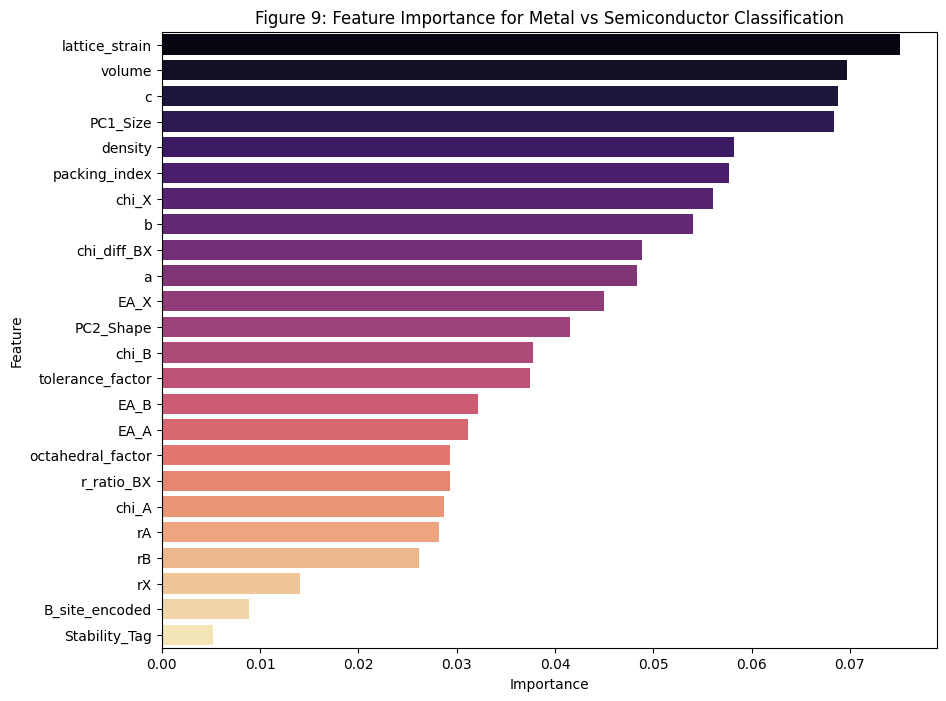

Top 5 Physical Drivers for Classification:
           Feature  Importance
18  lattice_strain    0.075101
14          volume    0.069702
2                c    0.068797
20        PC1_Size    0.068352
15         density    0.058230


In [4]:
# 1. GET FEATURE IMPORTANCES
importances = clf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 2. PLOT THE RESULTS
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title('Figure 9: Feature Importance for Metal vs Semiconductor Classification')
plt.show()

print("Top 5 Physical Drivers for Classification:")
print(feature_importance_df.head(5))

In [5]:
from sklearn.model_selection import GridSearchCV
import joblib

# 1. HYPERPARAMETER TUNING (Searching for the Best "Knobs")
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'criterion': ['gini', 'entropy']
}

print("Running Grid Search Optimization... (This may take a minute)")
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, n_jobs=-1)
grid_search.fit(X_train, y_train)

best_clf = grid_search.best_estimator_
print(f"✅ Optimization Complete! Best Parameters: {grid_search.best_params_}")
print(f"New Optimized Accuracy: {best_clf.score(X_test, y_test)*100:.2f}%")

# 2. SAVE THE TRAINED MODEL
# This saves the "Brain" of your AI so you can use it in any future notebook
joblib.dump(best_clf, 'Perovskite_Classifier_Model.joblib')
print("✅ Model saved as: Perovskite_Classifier_Model.joblib")

# 3. DATA PARTITIONING FOR STEP 4
# We create a specific dataframe for ONLY semiconductors
# We use the original band_gap values here for the Regressor to learn from
df_semiconductors = df[df['is_semiconductor'] == 1].copy()

# Save this "Pure" dataset for the next notebook
df_semiconductors.to_csv('Semiconductors_Only_Data.csv', index=False)

print(f"\n--- Transition to Step 4 ---")
print(f"Semiconductor Dataset Saved: Semiconductors_Only_Data.csv")
print(f"Total samples for Regression: {len(df_semiconductors)}")

Running Grid Search Optimization... (This may take a minute)
✅ Optimization Complete! Best Parameters: {'criterion': 'gini', 'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}
New Optimized Accuracy: 82.44%
✅ Model saved as: Perovskite_Classifier_Model.joblib

--- Transition to Step 4 ---
Semiconductor Dataset Saved: Semiconductors_Only_Data.csv
Total samples for Regression: 1831
